In [5]:
import stim

## Compile sampler

In [3]:
circuit = stim.Circuit()

circuit.append("H", [0])
circuit.append("CNOT", [0, 1])

circuit.append("M", [0, 1])

In [7]:
circuit.diagram()

q0: -H-@-M:rec[0]-
       |
q1: ---X-M:rec[1]-

In [8]:
sampler = circuit.compile_sampler()
print(sampler.sample(shots=10))

[[ True  True]
 [False False]
 [False False]
 [False False]
 [ True  True]
 [ True  True]
 [False False]
 [False False]
 [ True  True]
 [ True  True]]


In [9]:
circuit.append("DETECTOR", [stim.target_rec(-1), stim.target_rec(-2)])
print(repr(circuit))

stim.Circuit('''
    H 0
    CX 0 1
    M 0 1
    DETECTOR rec[-1] rec[-2]
''')


In [11]:
sampler = circuit.compile_detector_sampler()
print(sampler.sample(shots=10))

[[False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]]


In [32]:
circuit = stim.Circuit("""
    H 0
    TICK

    CX 0 1
    X_ERROR(0.2) 0 1
    TICK

    M 0 1
    DETECTOR rec[-1] rec[-2]
""")
print(circuit)

sampler = circuit.compile_detector_sampler()
print(sampler.sample(shots=10))

H 0
TICK
CX 0 1
X_ERROR(0.2) 0 1
TICK
M 0 1
DETECTOR rec[-1] rec[-2]
[[False]
 [False]
 [False]
 [ True]
 [ True]
 [False]
 [False]
 [False]
 [ True]
 [False]]


In [34]:
import numpy as np
print(np.sum(sampler.sample(shots=10000))/10000)

0.3211


R 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16
TICK
DEPOLARIZE1(0.04) 0 2 4 6 8 10 12 14 16
CX 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
TICK
CX 2 1 4 3 6 5 8 7 10 9 12 11 14 13 16 15
TICK
X_ERROR(0.01) 1 3 5 7 9 11 13 15
MR 1 3 5 7 9 11 13 15
DETECTOR(1, 0) rec[-8]
DETECTOR(3, 0) rec[-7]
DETECTOR(5, 0) rec[-6]
DETECTOR(7, 0) rec[-5]
DETECTOR(9, 0) rec[-4]
DETECTOR(11, 0) rec[-3]
DETECTOR(13, 0) rec[-2]
DETECTOR(15, 0) rec[-1]
REPEAT 24 {
    TICK
    DEPOLARIZE1(0.04) 0 2 4 6 8 10 12 14 16
    CX 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
    TICK
    CX 2 1 4 3 6 5 8 7 10 9 12 11 14 13 16 15
    TICK
    X_ERROR(0.01) 1 3 5 7 9 11 13 15
    MR 1 3 5 7 9 11 13 15
    SHIFT_COORDS(0, 1)
    DETECTOR(1, 0) rec[-8] rec[-16]
    DETECTOR(3, 0) rec[-7] rec[-15]
    DETECTOR(5, 0) rec[-6] rec[-14]
    DETECTOR(7, 0) rec[-5] rec[-13]
    DETECTOR(9, 0) rec[-4] rec[-12]
    DETECTOR(11, 0) rec[-3] rec[-11]
    DETECTOR(13, 0) rec[-2] rec[-10]
    DETECTOR(15, 0) rec[-1] rec[-9]
}
X_ERROR(0.01) 0 2 4 6 8 1

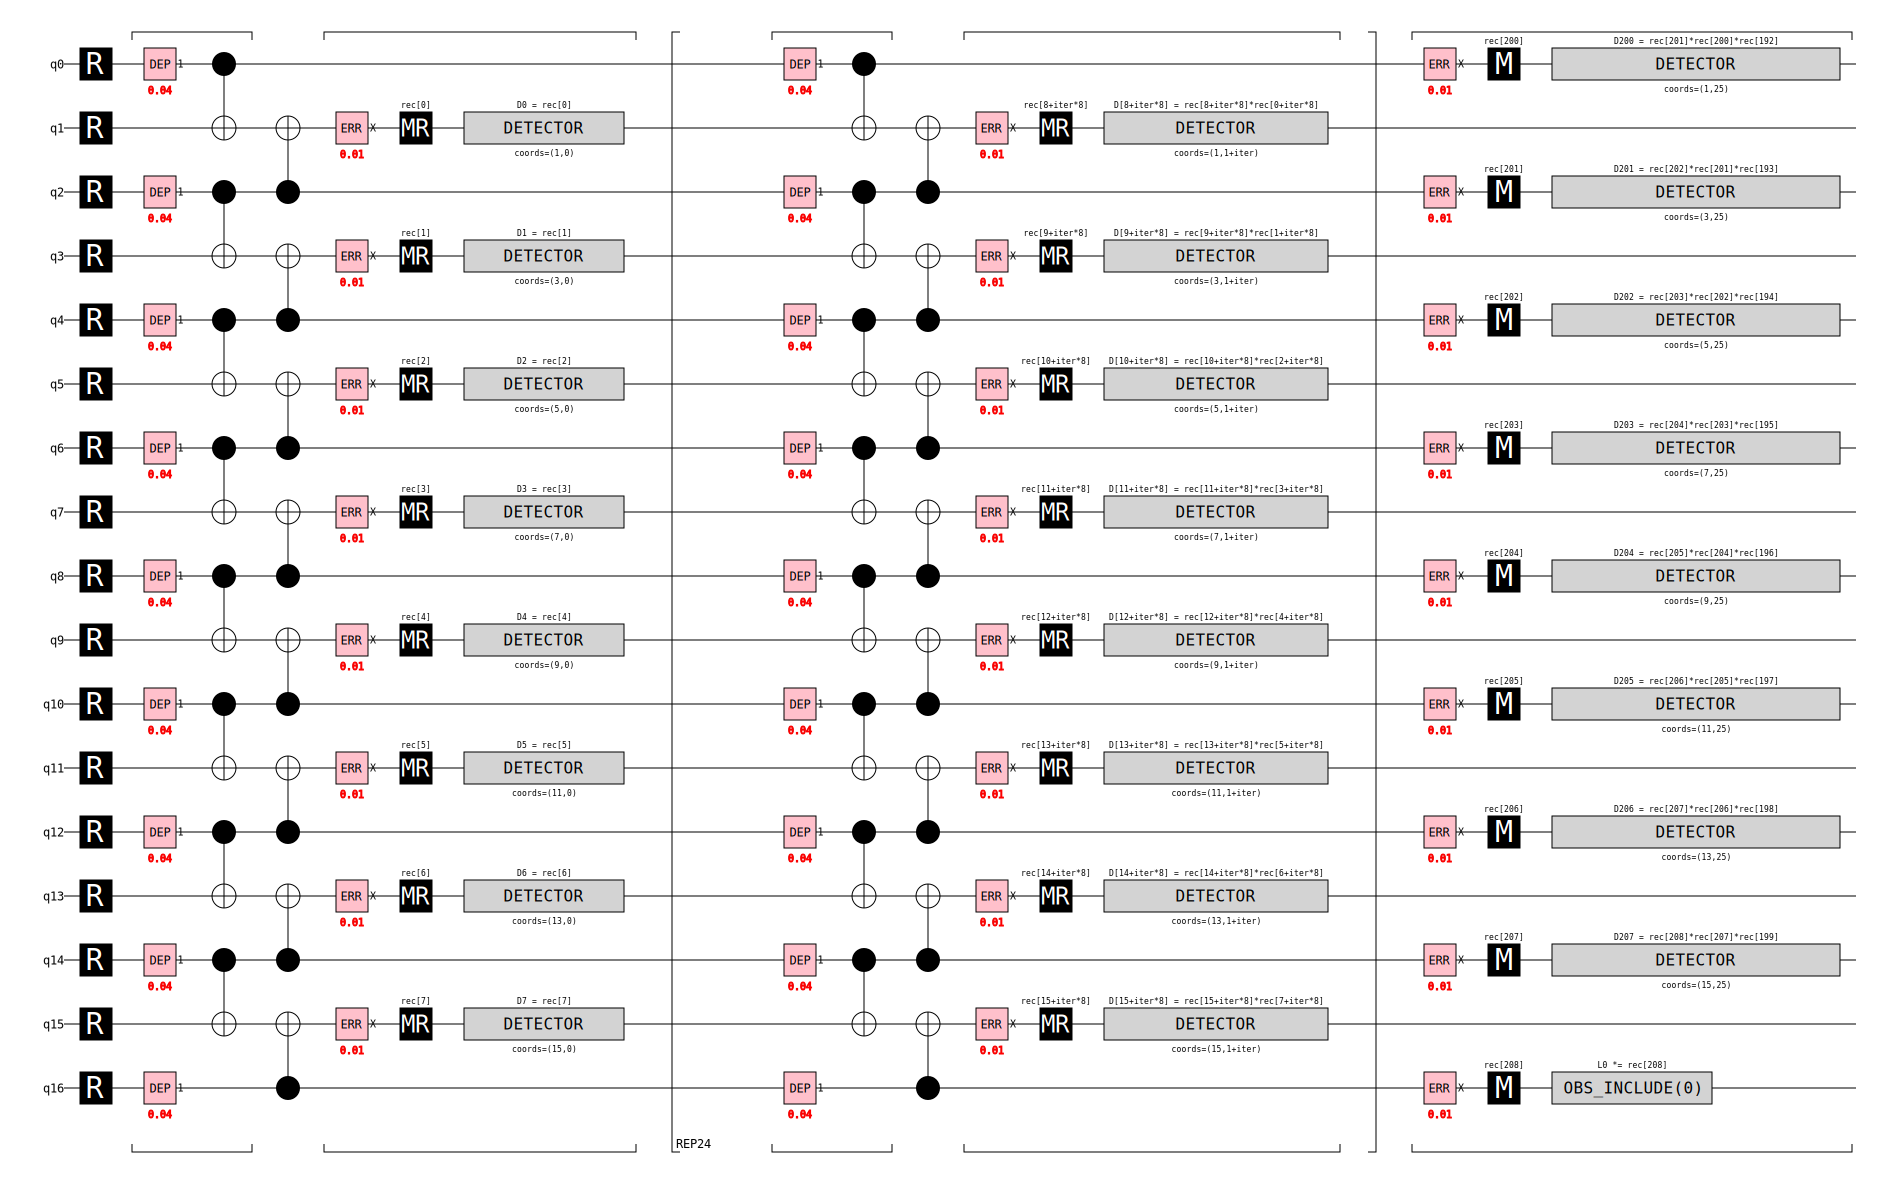

In [23]:
circuit = stim.Circuit.generated(
    "repetition_code:memory",
    rounds = 25,
    distance = 9,
    before_round_data_depolarization=0.04,
    before_measure_flip_probability=0.01
)
print(circuit)
circuit.diagram('timeline-svg')

In [24]:
sampler = circuit.compile_sampler()
one_sample = sampler.sample(shots=1)[0]
for k in range(0, len(one_sample), 8):
    timeslice = one_sample[k:k+8]
    print("".join("1" if e else "_" for e in timeslice))

________
________
______11
______11
______11
______11
______11
___11___
___11__1
___11___
___11___
___11___
___11___
________
____11__
__1_11__
____11__
____11__
____11__
____11__
____11__
_1__11__
_1__11__
____11__
____11__
_____1_1
_


In [29]:
sampler = circuit.compile_detector_sampler()
one_sample = sampler.sample(shots=1)[0]
for k in range(0, len(one_sample), 8):
    timeslice = one_sample[k:k+8]
    print("".join("!" if e else "_" for e in timeslice))

________
!_______
_____!!_
________
________
________
________
_!______
_!_____!
_____!!!
________
________
________
________
________
________
________
______!!
______!_
________
!___!___
!___!___
________
________
________
________


## stim.Tableau

`stim.Tableau` is the static Clifford-operation object. It tells you how Pauli operators are transformed by a Clifford circuit or gate.

In [14]:
h_tableau = stim.Tableau.from_named_gate("H")
print(h_tableau)
print(h_tableau.to_circuit())
print(h_tableau.x_output(0), h_tableau.z_output(0))
h_tableau_inverse = h_tableau.inverse()
print(h_tableau_inverse)


+-xz-
| ++
| ZX
H 0
+Z +X
+-xz-
| ++
| ZX


In [15]:
s_tableau = stim.Tableau.from_named_gate("S")
print(s_tableau)
print(s_tableau.to_circuit())
print(s_tableau.x_output(0), s_tableau.z_output(0))
s_tableau_inverse = s_tableau.inverse()
print(s_tableau_inverse)

+-xz-
| ++
| YZ
S 0
+Y +Z
+-xz-
| -+
| YZ


In [16]:
for k, tableau in enumerate(stim.Tableau.iter_all(num_qubits=1)):
    print(f"Single qubit Clifford #{k}:")
    print(tableau)
    print(tableau.to_circuit())
    print()

Single qubit Clifford #0:
+-xz-
| --
| XZ
H 0
S 0 0
H 0
S 0 0

Single qubit Clifford #1:
+-xz-
| +-
| XZ
H 0
S 0 0
H 0

Single qubit Clifford #2:
+-xz-
| -+
| XZ
S 0 0

Single qubit Clifford #3:
+-xz-
| ++
| XZ
H 0 0

Single qubit Clifford #4:
+-xz-
| --
| XY
S 0
H 0
S 0 0 0

Single qubit Clifford #5:
+-xz-
| +-
| XY
S 0
H 0
S 0
H 0
S 0 0
H 0

Single qubit Clifford #6:
+-xz-
| -+
| XY
S 0
H 0
S 0
H 0
S 0 0
H 0
S 0 0

Single qubit Clifford #7:
+-xz-
| ++
| XY
S 0
H 0
S 0

Single qubit Clifford #8:
+-xz-
| --
| ZX
H 0 0
S 0 0
H 0
S 0 0

Single qubit Clifford #9:
+-xz-
| +-
| ZX
H 0
S 0 0

Single qubit Clifford #10:
+-xz-
| -+
| ZX
H 0 0
S 0 0
H 0

Single qubit Clifford #11:
+-xz-
| ++
| ZX
H 0

Single qubit Clifford #12:
+-xz-
| --
| ZY
H 0
S 0
H 0
S 0 0
H 0

Single qubit Clifford #13:
+-xz-
| +-
| ZY
H 0
S 0 0 0

Single qubit Clifford #14:
+-xz-
| -+
| ZY
H 0
S 0
H 0
S 0 0
H 0
S 0 0

Single qubit Clifford #15:
+-xz-
| ++
| ZY
H 0
S 0

Single qubit Clifford #16:
+-xz-
| --
| YX
S 0
H 0 0

In [18]:
# A Tableau represents how a Clifford gate maps Pauli operators.
h_tableau = stim.Tableau.from_named_gate("H")

print("Hadamard tableau:")
print(h_tableau)
print("H maps X ->", h_tableau.x_output(0))
print("H maps Z ->", h_tableau.z_output(0))

# You can also get the tableau for a Clifford circuit.
bell_circuit = stim.Circuit("""
    H 0
    CX 0 1
""")
bell_tableau = stim.Tableau.from_circuit(bell_circuit)

print("\nBell-preparation tableau:")
print(bell_tableau)
print("X0 ->", bell_tableau.x_output(0))
print("Z0 ->", bell_tableau.z_output(0))
print("X1 ->", bell_tableau.x_output(1))
print("Z1 ->", bell_tableau.z_output(1))

Hadamard tableau:
+-xz-
| ++
| ZX
H maps X -> +Z
H maps Z -> +X

Bell-preparation tableau:
+-xz-xz-
| ++ ++
| ZX _Z
| _X XZ
X0 -> +Z_
Z0 -> +XX
X1 -> +_X
Z1 -> +ZZ


## stim.TableauSimulator

`stim.TableauSimulator` is the dynamic stabilizer-state simulator. You apply gates to a state, inspect stabilizers or observables, and perform measurements.

In [31]:
# TableauSimulator keeps track of the current stabilizer state.
sim = stim.TableauSimulator()
sim.h(0)
sim.cx(0, 1)

print("Bell-state stabilizers:")
for stabilizer in sim.canonical_stabilizers():
    print(stabilizer)

print("\n<XX> =", sim.peek_observable_expectation(stim.PauliString("XX")))
print("<ZZ> =", sim.peek_observable_expectation(stim.PauliString("ZZ")))
print("<ZI> =", sim.peek_observable_expectation(stim.PauliString("ZI")))

print("\nRepeated Z-basis Bell measurements:")
for _ in range(10):
    shot = stim.TableauSimulator()
    shot.h(0)
    shot.cx(0, 1)
    print(shot.measure_many(0, 1))

Bell-state stabilizers:
+XX
+ZZ

<XX> = 1
<ZZ> = 1
<ZI> = 0

Repeated Z-basis Bell measurements:
[True, True]
[True, True]
[False, False]
[False, False]
[False, False]
[True, True]
[False, False]
[False, False]
[True, True]
[False, False]
